# ROC analysis

In [1]:
import pathlib
import pickle

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from cycler import cycler

# Import utility variables
from navigoquest.utils.config import PLOT_CONFIG
from navigoquest.utils.analysis import (
    load_level_data,
    roc_curves,
    aucs,
    pvalues,
    percentiles,
    clinical_aucs,
    clinical_roc_curves,
)
import navigoquest.utils.plotutils as pu

In [2]:
root_dir = pathlib.Path.cwd().parent
data_dir = root_dir / "data"

metrics_dir = data_dir / "metrics"
plot_data_dir = data_dir / "data_for_plots"
figures_dir = root_dir / "figures"

## Uncomment below for coarse metrics
# metrics_dir = data_dir / "metrics_coarse"
# plot_data_dir = data_dir / "data_for_plots_coarse"

plot_data_dir.mkdir(parents=True, exist_ok=True)

## utils.config variables
title = PLOT_CONFIG["title"]
feat_types = PLOT_CONFIG["feat_types"]
short_title = PLOT_CONFIG["short_title"]

In [3]:
# Set font sizes
SMALL_SIZE = 9
MEDIUM_SIZE = 10
BIGGER_SIZE = 12

plt.rc("font", size=SMALL_SIZE)
plt.rc("axes", titlesize=MEDIUM_SIZE)
plt.rc("axes", labelsize=MEDIUM_SIZE)
plt.rc("xtick", labelsize=SMALL_SIZE)
plt.rc("ytick", labelsize=SMALL_SIZE)
plt.rc("legend", fontsize=SMALL_SIZE)
plt.rc("figure", titlesize=BIGGER_SIZE)

plt.rc("font", **{"family": "sans-serif", "sans-serif": ["Arial"]})

# The default cycler
orig_cycler = plt.rcParams.get("axes.prop_cycle")

In [4]:
set3_colors = list(plt.get_cmap("Set3").colors)
set3_colors.pop(1)  # the same as Peixoto does in graph-tool
set3_cycler = cycler(color=set3_colors)

set3_colors_mod = [set3_colors[0], set3_colors[2], set3_colors[1]]
set3_mod_cycler = cycler(color=set3_colors_mod)

# Figure 4

In [5]:
for NORM in [True, False]:
    # Level 6 for the feature separation depending on VO
    lvl = 6
    
    df = load_level_data(metrics_dir, lvl, norm=NORM)
    age_filter = df.age >= 50
    df = df.loc[age_filter].copy()
    idx = df["voc"].astype(bool)
    
    filename = plot_data_dir / f"dataframe_level{lvl:02}{'_normed' if NORM else ''}.pkl"
    
    with open(filename, "wb") as f:
        pickle.dump({"df": df, "idx": idx}, f)
        # print(f"\nSaved level {lvl} to: {filename}\n")
    
    # ROC curves (three levels)
    roc_xy = roc_curves(metrics_dir, feat_types, norm=NORM)
    filename = plot_data_dir / f"roc_three-levels{'_normed' if NORM else ''}.pkl"
    
    with open(filename, "wb") as f:
        pickle.dump({"roc_xy": roc_xy}, f)
        # print("\nSaved roc data to: ", filename)
    
    # AUC + p-vals (three levels)
    comparison_df = aucs(metrics_dir, feat_types, norm=NORM).join(pvalues(metrics_dir, feat_types))
    
    filename = plot_data_dir / f"auc-pvals_three-levels{'_normed' if NORM else ''}.pkl"
    
    comparison_df.to_pickle(filename)
    # print("\nSaved auc data to: ", filename)

In [6]:
NORM = False

# VO plot
vo_filename = plot_data_dir / f"dataframe_level06{'_normed' if NORM else ''}.pkl"
assert vo_filename.is_file()


# ROC curves
roc_filename = plot_data_dir / f"roc_three-levels{'_normed' if NORM else ''}.pkl"
assert roc_filename.is_file()

with open(roc_filename, "rb") as f:
    roc_xy = pickle.load(f)["roc_xy"]

# AUC values
auc_filename = plot_data_dir / f"auc-pvals_three-levels{'_normed' if NORM else ''}.pkl"
assert auc_filename.is_file()

comparison_df = pd.read_pickle(auc_filename).reset_index()

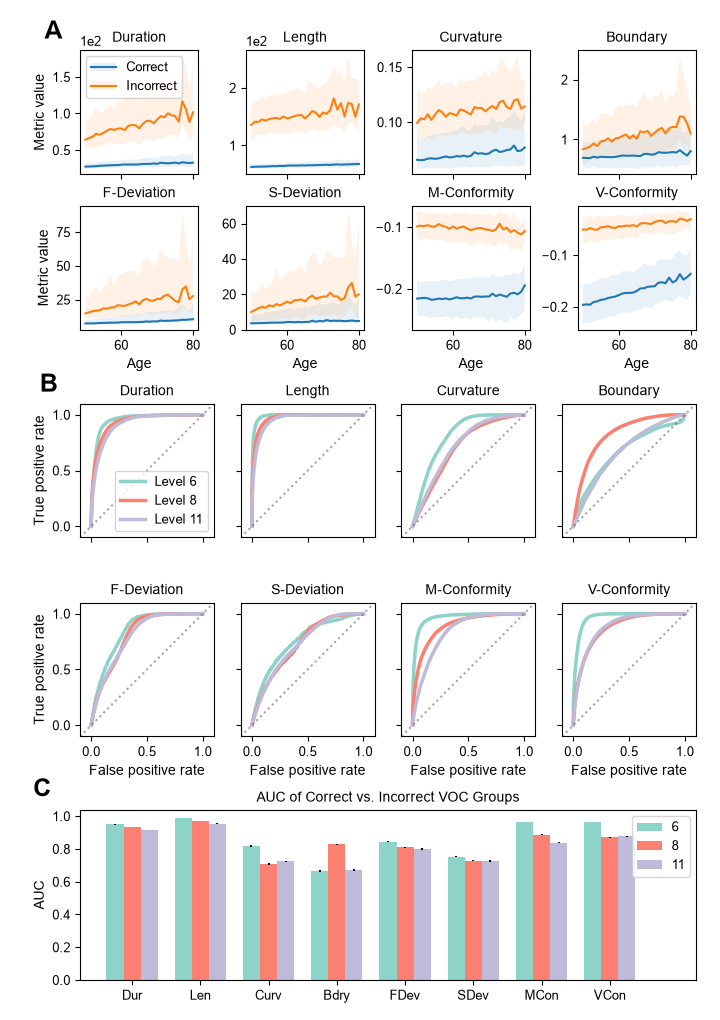

In [7]:
fig = plt.figure(figsize=(7, 10))  # contrained_layout=True

gs_a = fig.add_gridspec(
    nrows=2,
    ncols=4,
    left=0.1,
    right=0.98,
    top=0.96,
    bottom=0.68,
    wspace=0.40,
    hspace=0.25,
)
gs_b = fig.add_gridspec(
    nrows=2,
    ncols=4,
    left=0.1,
    right=0.98,
    top=0.65,
    bottom=0.23,
    hspace=-0.1,
)
gs_c = fig.add_gridspec(
    nrows=1,
    ncols=1,
    left=0.1,
    right=0.98,
    top=0.2,
    bottom=0.03,
    # wspace=0.1,
    # width_ratios=(1, 1, 1, 0.1),
)

panel_label_axes = []


# Panel A
for i, subplot_spec in enumerate(gs_a):
    ax = fig.add_subplot(subplot_spec)  # sharex=ax0 can be passed

    leg = i == 0
    pu.plot_quartiles_by_vo(ax, vo_filename, feat_types[i], legend=leg)
    ax.ticklabel_format(axis="y", style="sci", scilimits=(-2, 2))
    ax.set_title(ax.get_ylabel())
    ax.set_ylabel("")

    if i // 4 == 0:  # top row
        plt.setp(ax.get_xticklabels(), visible=False)
        ax.set_xlabel("")

    if i == 0:
        panel_label_axes.append(ax)

    if i % 4 == 0: # leftmost axes
        ax.set_ylabel("Metric value")

# Panel B
with mpl.rc_context({"axes.prop_cycle": set3_mod_cycler}):
    for i, subplot_spec in enumerate(gs_b):
        ax = fig.add_subplot(subplot_spec, aspect="equal")

        leg = i == 0
        pu.plot_roc_curves(ax, roc_xy, feat_types[i], legend=leg)

        if i // 4 == 0:  # top row
            plt.setp(ax.get_xticklabels(), visible=False)
            ax.set_xlabel("")

        if i % 4 != 0:  # all but left col
            plt.setp(ax.get_yticklabels(), visible=False)
            ax.set_ylabel("")

        if i == 0:
            panel_label_axes.append(ax)

# Panel C
with mpl.rc_context({"axes.prop_cycle": set3_mod_cycler}):
    axes_c = [fig.add_subplot(ss) for ss in gs_c]
    ax = axes_c[0]

    pu.plot_auc_bars(ax, comparison_df, title="AUC of Correct vs. Incorrect VOC Groups")
    
    panel_label_axes.append(ax)
    

# Background, labels, and annotations
pu.Background(visible=False)
pu.add_panel_labels(fig, axes=panel_label_axes, fontsize=18, xs=[-0.3, -0.3, -0.076])  # ys

# Figure 5

In [8]:
NORM = False

p_df = percentiles(metrics_dir, norm=NORM)
p_df = p_df.loc[p_df.group != "e4e4"]
gby = p_df.groupby(["level", "group"])[feat_types]
med = gby.median()

filename = plot_data_dir / f"percentiles_median{'_normed' if NORM else ''}.pkl"
med.to_pickle(filename)

In [9]:
NORM = True

p_df = percentiles(metrics_dir, norm=NORM)
p_df = p_df.loc[p_df.group != "e4e4"]
gby = p_df.groupby(["level", "group"])[feat_types]
med = gby.median()

# filename = plot_data_dir / f"percentiles_median{'_normed' if NORM else ''}.pkl"
# med.to_pickle(filename)

In [10]:
NORM = False

ref = "e3e3"

for other in ["ad", "e3e4"]:
    filename = plot_data_dir / f"auc-clinical_{ref}-{other}{'_normed' if NORM else ''}.pkl"

    auc_df = clinical_aucs(p_df, other, ref="e3e3").reset_index()
    auc_df.to_pickle(filename)

In [11]:
percentiles_filename = plot_data_dir / "percentiles_median.pkl"
med = pd.read_pickle(percentiles_filename)

In [12]:
groups = ["e3e3", "e3e4", "ad"]
levels = [6, 8, 11]
colors = np.array(orig_cycler.by_key()["color"])[[2, 0, 1]]

# radii = [0, 20, 40, 60, 80, 100]
# labels = [None, 20, None,60, None, 100]
radii = [0, 50, 100]
labels = [None, 50, 100]

theta = pu.radar_factory(len(feat_types))

In [13]:
panel_b_titles = {
    "ad": r"AUC of AD vs. $\epsilon3 \epsilon3$",
    "e3e4": r"AUC of $\epsilon3 \epsilon4$ vs. $\epsilon3 \epsilon3$",
}

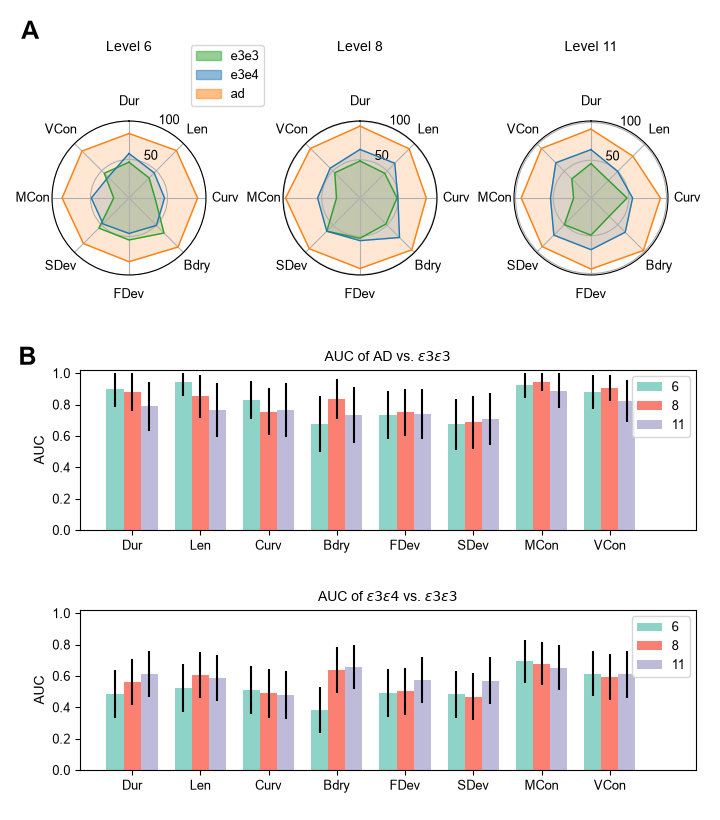

In [14]:
fig = plt.figure(figsize=(7, 8))

gs_a = fig.add_gridspec(
    nrows=1,
    ncols=3,
    wspace=0.5,
    bottom=0.63,
    top=0.9,
    left=0.06,
    right=0.94,
)

gs_b = fig.add_gridspec(
    nrows=2,
    ncols=1,
    wspace=0.5,
    bottom=0.05,
    top=0.55,
    left=0.1,
    right=0.98,
    hspace=0.5,
)

panel_label_axes = []

# Panel A
axs = gs_a.subplots(subplot_kw=dict(projection="radar"))

for ax, lvl in zip(axs, levels):
    leg = lvl == 6
    pu.radar(ax, med.loc[lvl], theta, groups, colors, radii=radii, labels=labels, legend=leg)
    ax.set_varlabels(short_title.values())
    ax.set_title(f"Level {lvl}", y=1.4)

panel_label_axes.append(axs[0])

# Panel B

with mpl.rc_context({"axes.prop_cycle": set3_mod_cycler}):
    for subplot_spec, (group, title) in zip(gs_b, panel_b_titles.items()):
        ax = fig.add_subplot(subplot_spec)

        clinical_auc = pd.read_pickle(plot_data_dir / f"auc-clinical_e3e3-{group}.pkl")
        pu.plot_auc_bars(ax, clinical_auc, title=title)
        ax.set_ylim(0, 1.02)

        if group == "ad":
            panel_label_axes.append(ax)

pu.Background(visible=False)
pu.add_panel_labels(fig, axes=panel_label_axes, fontsize=18, xs=[-0.2, -0.1], ys=[1.5, 1])

# ROC curves for the Appendix

In [15]:
clinical_df = pd.read_csv(metrics_dir / "clinical_metrics.csv")

for other in ["ad", "e3e4"]:
    roc_xy = clinical_roc_curves(clinical_df, other)
    filename = plot_data_dir / f"roc-clinical_e3e3-{other}.pkl"

    with open(filename, "wb") as f:
        pickle.dump({"roc_xy": roc_xy}, f)

In [16]:
roc_ad = pd.read_pickle(plot_data_dir / f"roc-clinical_e3e3-ad.pkl")["roc_xy"]
roc_e4 = pd.read_pickle(plot_data_dir / f"roc-clinical_e3e3-e3e4.pkl")["roc_xy"]

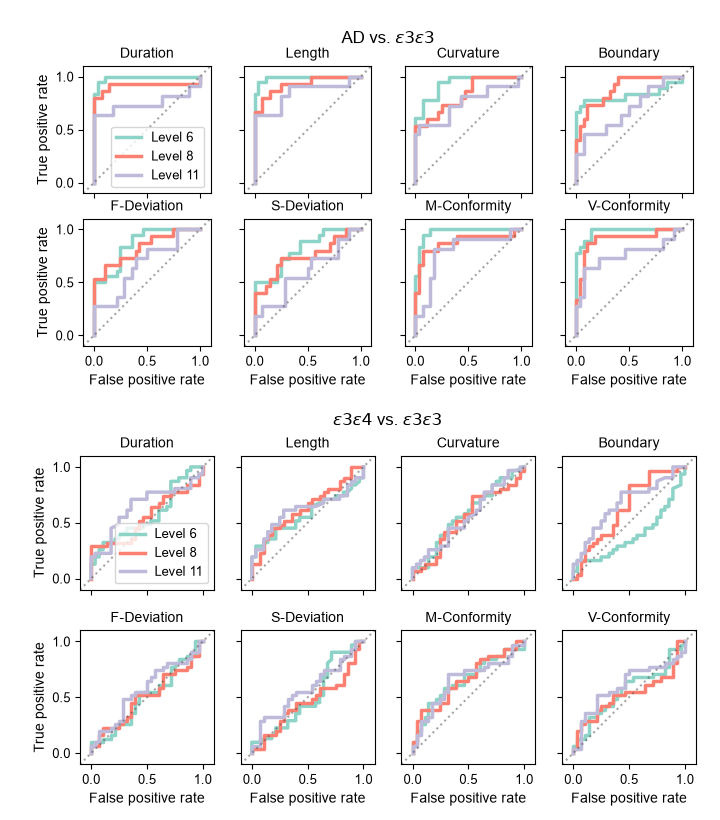

In [17]:
fig = plt.figure(figsize=(7, 8))  # contrained_layout=True

gs_a = fig.add_gridspec(
    nrows=2,
    ncols=4,
    left=0.1,
    right=0.98,
    top=0.93,
    bottom=0.58,
    # hspace=-0.1,
)

gs_b = fig.add_gridspec(
    nrows=2,
    ncols=4,
    left=0.1,
    right=0.98,
    top=0.45,
    bottom=0.05,
    # hspace=-0.1,
)

panel_label_axes = []

# Panel A
with mpl.rc_context({"axes.prop_cycle": set3_mod_cycler}):
    for i, subplot_spec in enumerate(gs_a):
        ax = fig.add_subplot(subplot_spec, aspect="equal")

        leg = i == 0
        pu.plot_roc_curves(ax, roc_ad, feat_types[i], legend=leg)

        if i // 4 == 0:  # top row
            plt.setp(ax.get_xticklabels(), visible=False)
            ax.set_xlabel("")

        if i % 4 != 0:  # all but left col
            plt.setp(ax.get_yticklabels(), visible=False)
            ax.set_ylabel("")

        if i == 0:
            panel_label_axes.append(ax)

# Panel B
with mpl.rc_context({"axes.prop_cycle": set3_mod_cycler}):
    for i, subplot_spec in enumerate(gs_b):
        ax = fig.add_subplot(subplot_spec, aspect="equal")

        leg = i == 0
        pu.plot_roc_curves(ax, roc_e4, feat_types[i], legend=leg)

        if i // 4 == 0:  # top row
            plt.setp(ax.get_xticklabels(), visible=False)
            ax.set_xlabel("")

        if i % 4 != 0:  # all but left col
            plt.setp(ax.get_yticklabels(), visible=False)
            ax.set_ylabel("")

        if i == 0:
            panel_label_axes.append(ax)


# Titles with ghost axs
ax_top = fig.add_subplot(gs_a[:])
ax_top.axis('off')
ax_top.set_title(r"AD vs. $\epsilon3\epsilon3$", y=1.05, fontdict={"size":BIGGER_SIZE})

ax_btm = fig.add_subplot(gs_b[:])
ax_btm.axis('off')
ax_btm.set_title(r"$\epsilon3\epsilon4$ vs. $\epsilon3\epsilon3$", y=1.05, fontdict={"size":BIGGER_SIZE})


pu.Background(visible=False);